In [48]:
import xarray as xr
from scipy.stats import pearsonr
import os.path
import datetime
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import netCDF4
import matplotlib.pyplot as plt
from matplotlib import dates
import matplotlib.cm as cm
# Generate 20 unique colors using a colormap
iro20 = cm.tab20(np.linspace(0, 1, 20))
import eatpy
from scipy.stats import qmc,spearmanr,pearsonr,iqr
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import glob
setup_dir = "."
varname = ["1p1z_no3","1p1z_chl","1p1z_SDeN","1p1z_LDeN"]

In [2]:
# Read in the ensemble size defined in a py file.
from importlib import reload
import generate_ensemble_yaml

# Reload the module
reload(generate_ensemble_yaml)

# Access the variable through the module
N = generate_ensemble_yaml.N

In [3]:
# Read in the ensemble parameter sets defined in a csv file.
sample_scaled = pd.read_csv('parameter-values-'+str(N)+'.csv')
name_para = sample_scaled.columns.tolist() # header, parameter names
sample_scaled

,attCHL,I_thNH4,D_p5NH4,NitriR,K_NO3,K_NH4,Vp0,K_Phy,PhyIS,PhyMR,...,ZooBM,ZooER,ZooGR,ZooMR,LDeRRN,SDeRRN,CoagR,wP,wL,wS
0,0.028,0.010,0.09,0.26,4.7,2.7,0.6,0.6,0.061,0.16,...,0.16,0.21,3.0,0.26,0.214,0.043,0.391,0.65,6.4,0.89
1,0.029,0.015,0.11,0.20,1.0,2.6,3.2,1.0,0.028,0.05,...,0.34,0.10,3.7,0.30,0.535,0.067,0.518,0.97,8.6,0.14
2,0.036,0.010,0.09,0.20,4.4,1.8,2.8,3.2,0.055,0.02,...,0.18,0.03,2.8,0.26,0.136,0.068,0.400,0.80,3.1,0.70
3,0.021,0.010,0.09,0.22,2.9,4.1,3.5,3.9,0.065,0.19,...,0.08,0.07,0.4,0.16,0.293,0.071,0.320,0.44,2.9,0.17
4,0.013,0.013,0.14,0.21,4.0,4.7,2.8,1.7,0.107,0.22,...,0.19,0.02,2.3,0.30,0.138,0.033,0.586,0.16,8.4,0.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.010,0.013,0.14,0.12,1.2,3.6,2.2,5.0,0.116,0.22,...,0.20,0.29,2.6,0.03,0.190,0.094,0.777,0.22,7.4,1.10
996,0.027,0.012,0.12,0.19,1.2,2.7,0.2,3.2,0.023,0.24,...,0.15,0.17,3.5,0.09,0.307,0.050,0.501,0.65,9.2,0.56
997,0.031,0.013,0.11,0.48,1.2,4.8,0.9,4.6,0.033,0.21,...,0.28,0.31,0.7,0.05,0.058,0.066,0.409,0.71,2.7,1.01
998,0.026,0.013,0.08,0.13,1.1,1.4,2.5,2.8,0.108,0.24,...,0.20,0.19,3.3,0.02,0.057,0.074,0.534,0.72,7.4,0.18


### Read ensemble outputs

In [56]:
# ファイルパスのリストを作成
file_paths = sorted(glob.glob("result_[0-9][0-9][0-9][0-9].nc"))

# `xr.open_mfdataset` を使用してファイルを結合
ds = xr.open_mfdataset(
    file_paths,
    concat_dim="ensemble",  # 新しい次元として 'ensemble' を追加
    combine="nested",       # 結合方法
    coords="minimal",       # 必要最小限の座標のみを保持
    compat="override",      # メタデータの競合を無視
    parallel=True,          # 並列処理を有効化（高速化）
)

# 'ensemble' 次元に番号を割り当てる
ds = ds.assign_coords(ensemble=range(len(file_paths)))

# Remove the last index in the time dimension which corresponds to Jan 1 1999
ds = ds.isel(time=slice(None, -1))

# 変数の抽出
time = ds['time']
z = ds['z'][0, :, 0, 0]

In [57]:
ds

<xarray.Dataset> Size: 13GB
Dimensions:                                                   (ensemble: 1000,
                                                               time: 365,
                                                               z: 110, lat: 1,
                                                               lon: 1, zi: 111)
Coordinates:
  * time                                                      (time) datetime64[ns] 3kB ...
  * lon                                                       (lon) float32 4B ...
  * lat                                                       (lat) float32 4B ...
    z                                                         (time, z, lat, lon) float32 161kB dask.array<chunksize=(365, 110, 1, 1), meta=np.ndarray>
    zi                                                        (time, zi, lat, lon) float32 162kB dask.array<chunksize=(365, 111, 1, 1), meta=np.ndarray>
  * ensemble                                                  (ensemble) int64 8kB ...
Data variables: (12/123)
    temp                                                      (ensemble, time, z, lat, lon) float32 161MB dask.array<chunksize=(1, 365, 110, 1, 1), meta=np.ndarray>
    salt                                                      (ensemble, time, z, lat, lon) float32 161MB dask.array<chunksize=(1, 365, 110, 1, 1), meta=np.ndarray>
    rho                                                       (ensemble, time, z, lat, lon) float32 161MB dask.array<chunksize=(1, 365, 110, 1, 1), meta=np.ndarray>
    temp_obs                                                  (ensemble, time, z, lat, lon) float32 161MB dask.array<chunksize=(1, 365, 110, 1, 1), meta=np.ndarray>
    salt_obs                                                  (ensemble, time, z, lat, lon) float32 161MB dask.array<chunksize=(1, 365, 110, 1, 1), meta=np.ndarray>
    u                                                         (ensemble, time, z, lat, lon) float32 161MB dask.array<chunksize=(1, 365, 110, 1, 1), meta=np.ndarray>
    ...                                                        ...
    1p1z_RemineL                                              (ensemble, time, z, lat, lon) float32 161MB dask.array<chunksize=(1, 365, 110, 1, 1), meta=np.ndarray>
    1p1z_Nitrifi                                              (ensemble, time, z, lat, lon) float32 161MB dask.array<chunksize=(1, 365, 110, 1, 1), meta=np.ndarray>
    light_par                                                 (ensemble, time, z, lat, lon) float32 161MB dask.array<chunksize=(1, 365, 110, 1, 1), meta=np.ndarray>
    attenuation_coefficient_of_photosynthetic_radiative_flux  (ensemble, time, z, lat, lon) float32 161MB dask.array<chunksize=(1, 365, 110, 1, 1), meta=np.ndarray>
    surface_drag_coefficient_in_air                           (ensemble, time, lat, lon) float32 1MB dask.array<chunksize=(1, 365, 1, 1), meta=np.ndarray>
    surface_albedo                                            (ensemble, time, lat, lon) float32 1MB dask.array<chunksize=(1, 365, 1, 1), meta=np.ndarray>
Attributes:
    title:    GOTM Simulation
    comment:  file created by flexout - https://github.com/BoldingBruggeman/f...

### Sea surface chlorophyll-a sensitivity

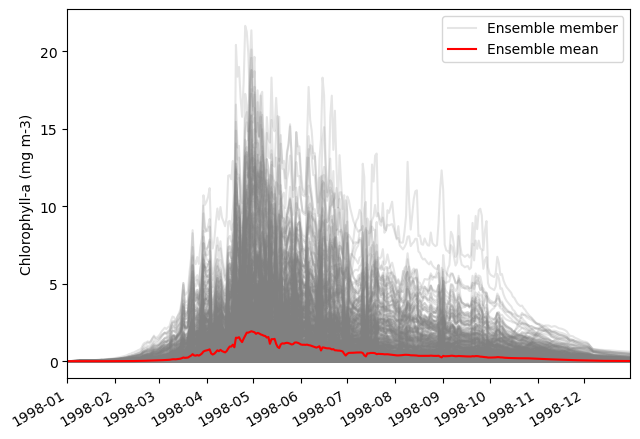

In [87]:
# obtain vertical time series (ensemble member, time, depth) of a selected variable
temps = ds["1p1z_chl"][:,:,:,0, 0]
# obtain time series in the uppermost layer (compare with satellite)
ssts = temps[:,:,-1]

fig = plt.figure()
# loop over ensemble members
for j in range(np.size(ssts,0)):
    plt.plot(time,ssts[j,:],c='gray',alpha=0.2)
plt.plot([],[],c='gray',alpha=0.2,label='Ensemble member')
plt.plot(time,np.mean(ssts,0),label='Ensemble mean',color='r')
#plt.plot(time,np.median(ssts,0),label='Median')
plt.ylabel('Chlorophyll-a (mg m-3)')
plt.legend()
plt.xlim(time[0],time[-1])
plt.tight_layout()
fig.autofmt_xdate()
plt.savefig('fig-SSCHL-'+str(N),dpi=300,bbox_inches='tight')

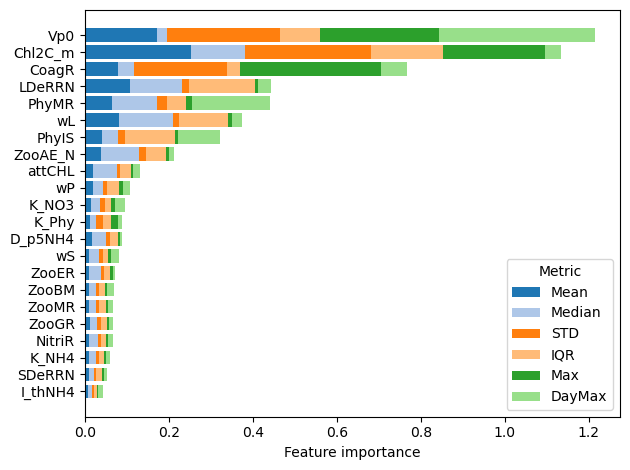

In [83]:
# calculate different metrics
n_metric = ['Mean','Median','STD','IQR','Max','DayMax']
v_metric = [np.mean(ssts,1),
            np.median(ssts,1),
            np.std(ssts,1),
            iqr(ssts,1),
            np.max(ssts,1),
            np.argmax(ssts,1) # note this is the index and not the datetime so that correlation can be calculated
           ]

df = pd.DataFrame({"Parameter": name_para})

for j in range(np.size(n_metric)):

    rf = RandomForestRegressor()
    rf.fit(sample_scaled, v_metric[j])
    df[n_metric[j]] = rf.feature_importances_
df['total'] = df[n_metric].sum(axis=1)    
df = df.sort_values(by="total", ascending=True)

plt.figure()
sum_prev = np.zeros(len(name_para))
for j in range(len(n_metric)):
    plt.barh(width=df[n_metric[j]],y=df['Parameter'],left=sum_prev,label=n_metric[j],color=iro20[j])
    sum_prev += df[n_metric[j]]

plt.xlabel('Feature importance')
plt.legend(title='Metric')
plt.tight_layout()
plt.savefig('fig-sensitivity-SSCHL-'+str(N),dpi=300,bbox_inches='tight')

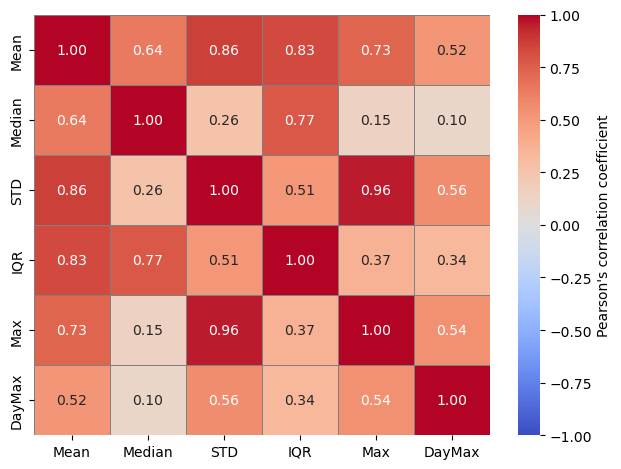

In [84]:
corr_matrix = df.drop(columns=['Parameter','total']).corr(method='pearson')
# Set the figure size
plt.figure()

# Create a heatmap
sns.heatmap(
    corr_matrix,
    annot=True,  # Show correlation values in the cells
    cmap='coolwarm',  # Color map (red for negative, blue for positive)
    center=0,  # Center the color map at 0
    vmin=-1,  # Minimum correlation value
    vmax=1,  # Maximum correlation value
    fmt=".2f",  # Format annotations to 2 decimal places
    linewidths=0.5,  # Add lines between cells
    linecolor='gray',  # Color of the lines
    cbar_kws={"label": "Pearson's correlation coefficient"}  # Add title to the colorbar
)
plt.tight_layout()
plt.savefig('fig-metric-correlation',dpi=300,bbox_inches='tight')

### Sea surface chlorophyll-a sensitivity at different lead times/months
- target: monthly mean

<Figure size 640x480 with 0 Axes>

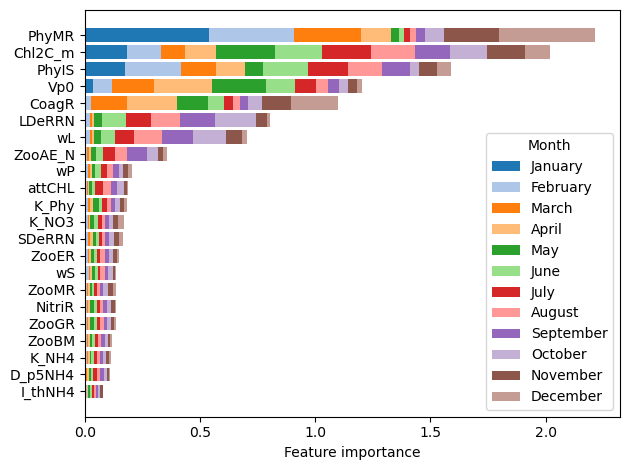

In [76]:
target = ds["1p1z_chl"].isel(z=-1).groupby('time.month').mean(dim='time')[:,:,0,0]

tsuki = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

df = pd.DataFrame({"Parameter": name_para})


fig = plt.figure()

for j in range(len(tsuki)):
    rf = RandomForestRegressor()
    rf.fit(sample_scaled, target[:,j])
    df[tsuki[j]] = rf.feature_importances_
df['total'] = df[tsuki].sum(axis=1)    
df = df.sort_values(by="total", ascending=True)

plt.figure()
sum_prev = np.zeros(len(name_para))
for j in range(len(tsuki)):
    plt.barh(width=df[tsuki[j]],y=df['Parameter'],left=sum_prev,label=tsuki[j],color=iro20[j])
    sum_prev += df[tsuki[j]]

plt.xlabel('Feature importance')
plt.legend(title='Month')
plt.tight_layout()
plt.savefig('fig-sensitivity-month-SSCHL-'+str(N),dpi=300,bbox_inches='tight')

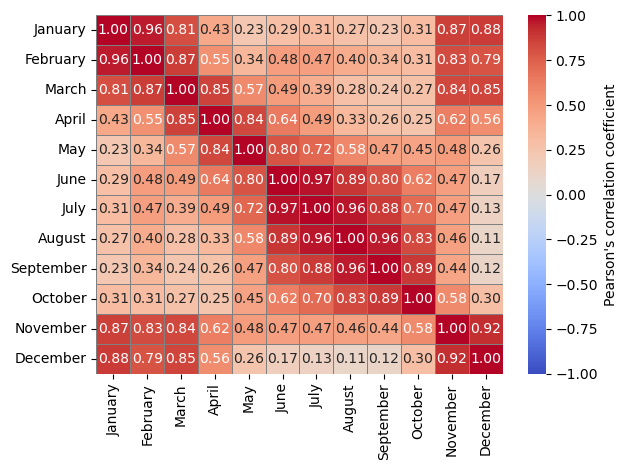

In [82]:
corr_matrix = df.drop(columns=['Parameter','total']).corr(method='pearson')
# Set the figure size
plt.figure()

# Create a heatmap
sns.heatmap(
    corr_matrix,
    annot=True,  # Show correlation values in the cells
    cmap='coolwarm',  # Color map (red for negative, blue for positive)
    center=0,  # Center the color map at 0
    vmin=-1,  # Minimum correlation value
    vmax=1,  # Maximum correlation value
    fmt=".2f",  # Format annotations to 2 decimal places
    linewidths=0.5,  # Add lines between cells
    linecolor='gray',  # Color of the lines
    cbar_kws={"label": "Pearson's correlation coefficient"}  # Add title to the colorbar
)
plt.tight_layout()
plt.savefig('fig-month-correlation',dpi=300,bbox_inches='tight')

### Variable-dependence on sensitivity
- target: upper 50-m average BGC variables

In [99]:
print(ds.z)


<xarray.DataArray 'z' (time: 365, z: 110, lat: 1, lon: 1)> Size: 161kB
dask.array<getitem, shape=(365, 110, 1, 1), dtype=float32, chunksize=(365, 110, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 1998-01-01 1998-01-02 ... 1998-12-31
  * lon      (lon) float32 4B 1.283
  * lat      (lat) float32 4B 59.33
    z        (time, z, lat, lon) float32 161kB dask.array<chunksize=(365, 110, 1, 1), meta=np.ndarray>
Attributes:
    units:          m
    long_name:      depth
    standard_name:  ??
    path:           /column_structure
    positive:       up
    axis:           Z


In [100]:
print(ds.dims)  # Check if 'z' is listed


FrozenMappingWarningOnValuesAccess({'ensemble': 1000, 'time': 365, 'z': 110, 'lat': 1, 'lon': 1, 'zi': 111})


In [93]:
varlist = ["no3","nh4","phy","chl","zoo","SDeN","LDeN"]
unilist = ["mmol m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$","mg m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$"]

for j in range(len(varlist)):
    target = ds['1p1z_'+varlist[j]].sel(z=slice(-50,None)).mean(dim=['time','z'])[:,0,0]

    df = pd.DataFrame({"Parameter": name_para})

    rf = RandomForestRegressor()
    rf.fit(sample_scaled, target)
    df[varlist[j]] = rf.feature_importances_
df['total'] = df[varlist].sum(axis=1)    
df = df.sort_values(by="total", ascending=True)

plt.figure()
sum_prev = np.zeros(len(name_para))
for j in range(len(varlist)):
    plt.barh(width=df[varlist[j]],y=df['Parameter'],left=sum_prev,label=varlist[j],color=iro20[j])
    sum_prev += df[varlist[j]]

plt.xlabel('Feature importance')
plt.legend(title='Variable')
plt.tight_layout()
plt.savefig('fig-sensitivity-variables-'+str(N),dpi=300,bbox_inches='tight')

KeyError: "no index found for coordinate 'z'"

### Biogeochemical ensemble mean and STD (this can take a long time to plot when ensemble size is large)
- upper 50 m is most important

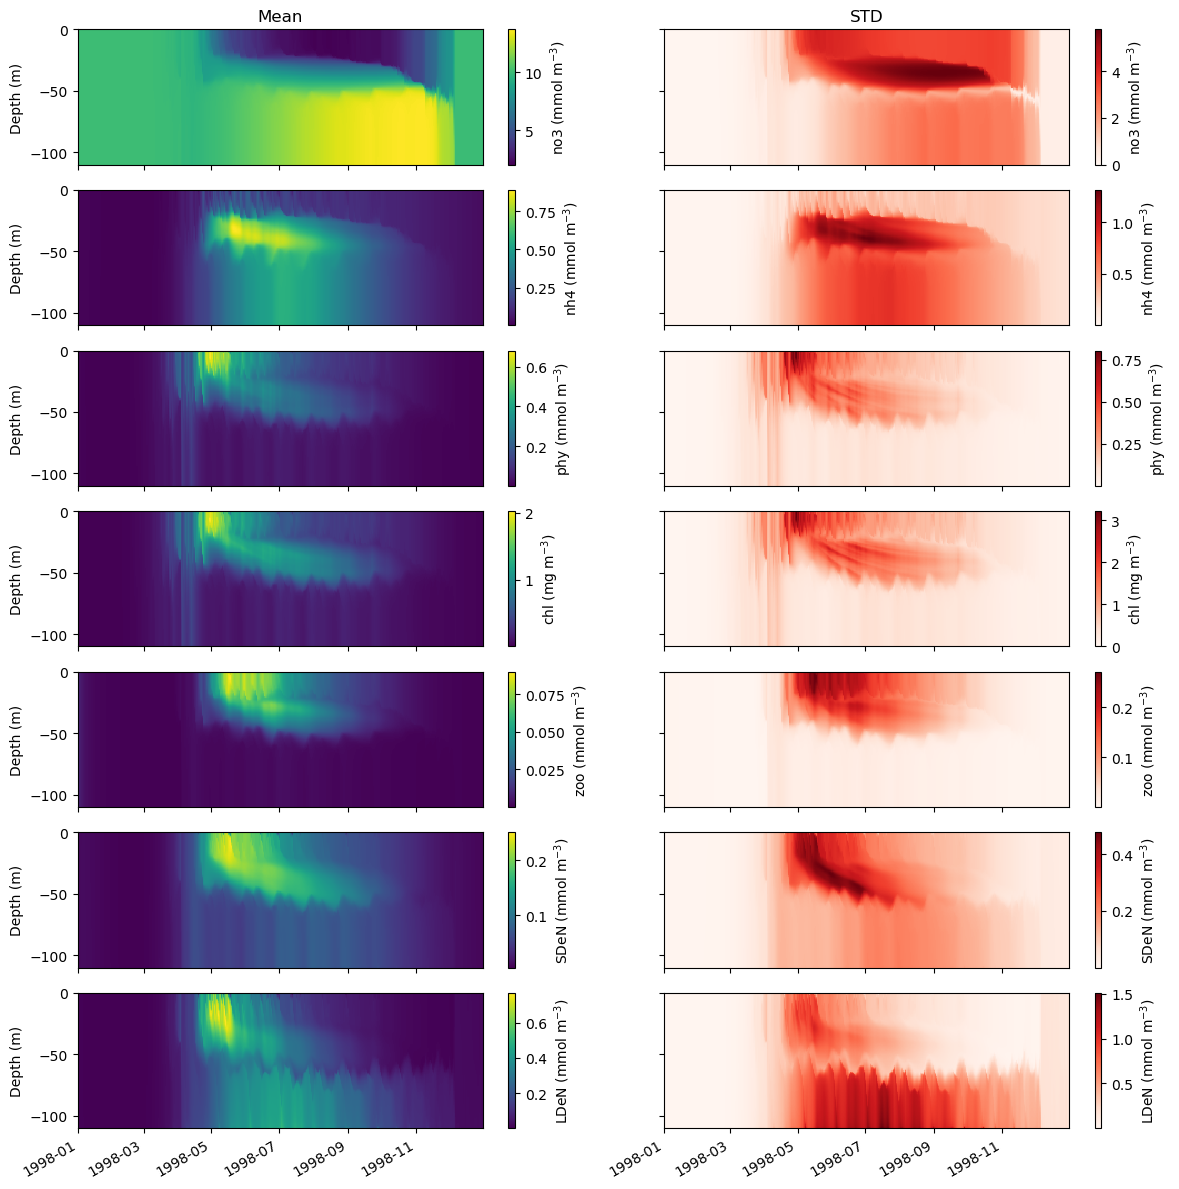

In [89]:
varlist = ["no3","nh4","phy","chl","zoo","SDeN","LDeN"]
unilist = ["mmol m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$","mg m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$","mmol m$^{-3}$"]

fig, axs = plt.subplots(7, 2, figsize=(12,12), sharex=True, sharey=True)

for j in range(len(varlist)):
    output = ds['1p1z_'+varlist[j]]

    mesh = axs[j, 0].pcolormesh(time,z,np.squeeze(output.mean(axis=0)).T)
    plt.colorbar(mesh).set_label(varlist[j]+' ('+unilist[j]+')')
    axs[j, 0].set_ylabel('Depth (m)')
    if j == 0:
        axs[j, 0].set_title('Mean')
    mesh = axs[j, 1].pcolormesh(time,z,np.squeeze(output.std(axis=0)).T,cmap='Reds')
    plt.colorbar(mesh).set_label(varlist[j]+' ('+unilist[j]+')')
    if j == 0:
        axs[j, 1].set_title('STD')

fig.autofmt_xdate()
plt.tight_layout()
# Manually adjust spacing (left, bottom, right, top, wspace, hspace)
#plt.subplots_adjust(wspace=0.15)  # Adjust vertical spacing between subplots

fig.savefig('fig-tz-bgc-'+str(N),dpi=300,bbox_inches='tight')

### Background physical environment (temperature, salinity, and density)

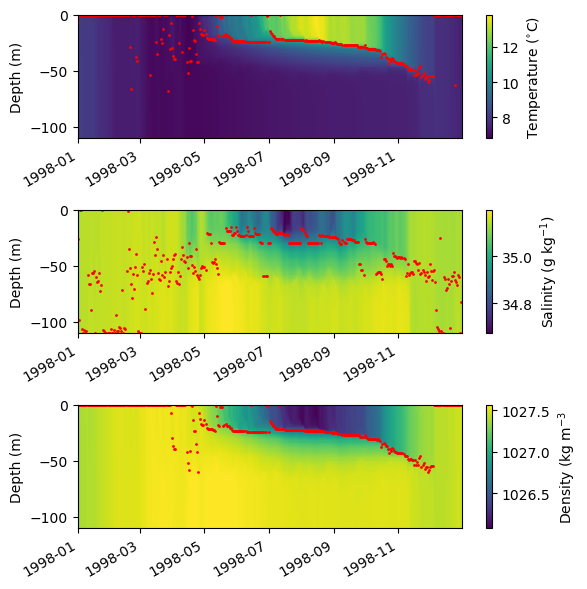

In [92]:
fig, axs = plt.subplots(3, 1, figsize=(6,6))

mesh = axs[0].pcolormesh(time,z,ds['temp'][0,:,:,0,0].T)
plt.colorbar(mesh).set_label('Temperature ($^{\circ}$C)')
axs[0].set_ylabel('Depth (m)')
mesh = axs[1].pcolormesh(time,z,ds['salt'][0,:,:,0,0].T)
plt.colorbar(mesh).set_label('Salinity (g kg$^{-1}$)')
axs[1].set_ylabel('Depth (m)')
mesh = axs[2].pcolormesh(time,z,ds['rho'][0,:,:,0,0].T)
plt.colorbar(mesh).set_label('Density (kg m$^{-3}$')
axs[2].set_ylabel('Depth (m)')

thermocline_depth = np.zeros(len(time))  # Array to store thermocline depths
halocline_depth = np.zeros(len(time))  # Array to store thermocline depths
pycnocline_depth = np.zeros(len(time))  # Array to store thermocline depths
for t in range(len(time)):
    gradient = np.gradient(ds['temp'][0,t,:,0,0], z, axis=0)
    max_gradient_index = np.argmax(np.abs(gradient))
    thermocline_depth[t] = z[max_gradient_index]
    gradient = np.gradient(ds['salt'][0,t,:,0,0], z, axis=0)
    max_gradient_index = np.argmax(np.abs(gradient))
    halocline_depth[t] = z[max_gradient_index]
    gradient = np.gradient(ds['rho'][0,t,:,0,0], z, axis=0)
    max_gradient_index = np.argmax(np.abs(gradient))
    pycnocline_depth[t] = z[max_gradient_index]
mesh = axs[0].scatter(time,thermocline_depth,c='r',s=1)
mesh = axs[1].scatter(time,halocline_depth,c='r',s=1)
mesh = axs[2].scatter(time,pycnocline_depth,c='r',s=1)

fig.autofmt_xdate()
plt.tight_layout()

fig.savefig('fig-tz-tsrho-'+str(N),dpi=300,bbox_inches='tight')